In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = "svg"

In [2]:
from google.colab import files
hotel_upload = files.upload()

Saving HotelCustomersDataset.xlsx to HotelCustomersDataset.xlsx


In [3]:
hotels = pd.read_excel("HotelCustomersDataset.xlsx")
hotels.head()

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
pd.ExcelFile("HotelCustomersDataset.xlsx").sheet_names

['Sheet1']

# Assignment 1: Subplots

Plot The distribution of lodging revenue for our top 5 countries by revenue ("PRT, "ESP", "FRA", "DEU", "GBR").

**Limit Data to Bookings with RoomNights < 15**

Make sure to share both x and y axes and give them titles!

Remove the extra chart with `ax[row, col].set_axis_off()` if using plt.subplots()


In [5]:
top_5_countries = hotels.groupby(["Nationality"]).agg({"LodgingRevenue":"sum"}).nlargest(5, columns="LodgingRevenue")
top_5_countries

,LodgingRevenue
Nationality,
FRA,3809315.59
DEU,3113382.55
PRT,2715008.72
GBR,2693123.61
ESP,1475909.33


In [6]:
index_countries = top_5_countries.index.tolist()
index_countries

['FRA', 'DEU', 'PRT', 'GBR', 'ESP']

In [7]:
for i in index_countries:
  print(i)

FRA
DEU
PRT
GBR
ESP


In [8]:
hotels.columns

Index(['ID', 'Nationality', 'Age', 'DaysSinceCreation', 'AverageLeadTime',
       'LodgingRevenue', 'OtherRevenue', 'BookingsCanceled',
       'BookingsNoShowed', 'BookingsCheckedIn', 'PersonsNights', 'RoomNights',
       'DaysSinceLastStay', 'DaysSinceFirstStay', 'DistributionChannel',
       'MarketSegment', 'SRHighFloor', 'SRLowFloor', 'SRAccessibleRoom',
       'SRMediumFloor', 'SRBathtub', 'SRShower', 'SRCrib', 'SRKingSizeBed',
       'SRTwinBed', 'SRNearElevator', 'SRAwayFromElevator',
       'SRNoAlcoholInMiniBar', 'SRQuietRoom'],
      dtype='object')

In [9]:
hotels[["Nationality" , "LodgingRevenue"]]

,Nationality,LodgingRevenue
0,PRT,371.0
1,PRT,280.0
2,DEU,0.0
3,FRA,240.0
4,FRA,0.0
...,...,...
83585,ITA,0.0
83586,IRL,327.1
83587,IRL,0.0
83588,IRL,981.3


In [10]:
RoomNights_Mask = hotels.RoomNights < 15

In [ ]:
index_countries

['FRA', 'DEU', 'PRT', 'GBR', 'ESP']

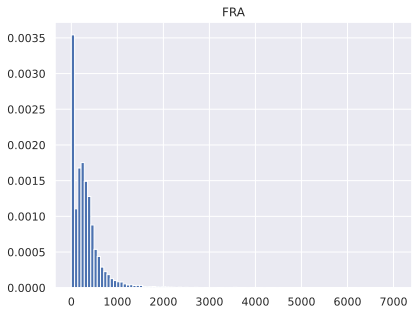

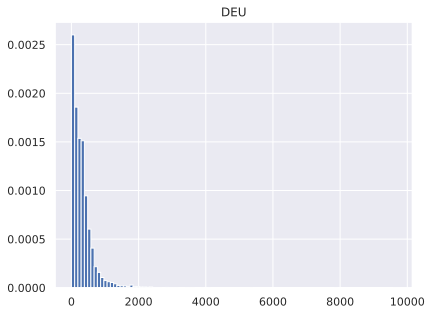

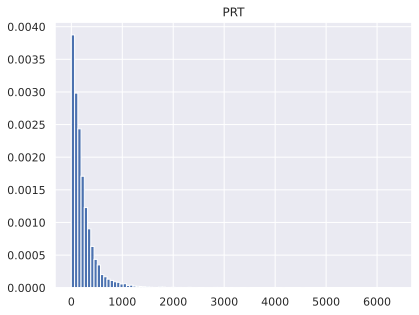

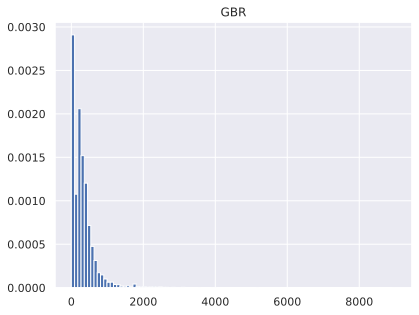

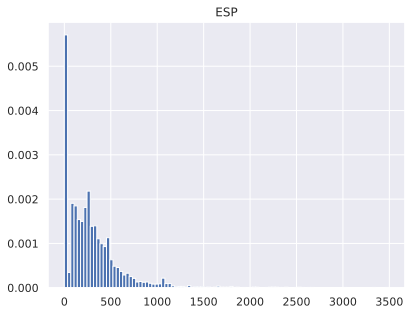

In [12]:
for country in index_countries:
  plt.hist(hotels.loc[(hotels.Nationality == country) & RoomNights_Mask, "LodgingRevenue"] , bins = 100 , density = True)
  plt.title(f"{country}")
  plt.show()

/tmp/ipython-input-3213272755.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


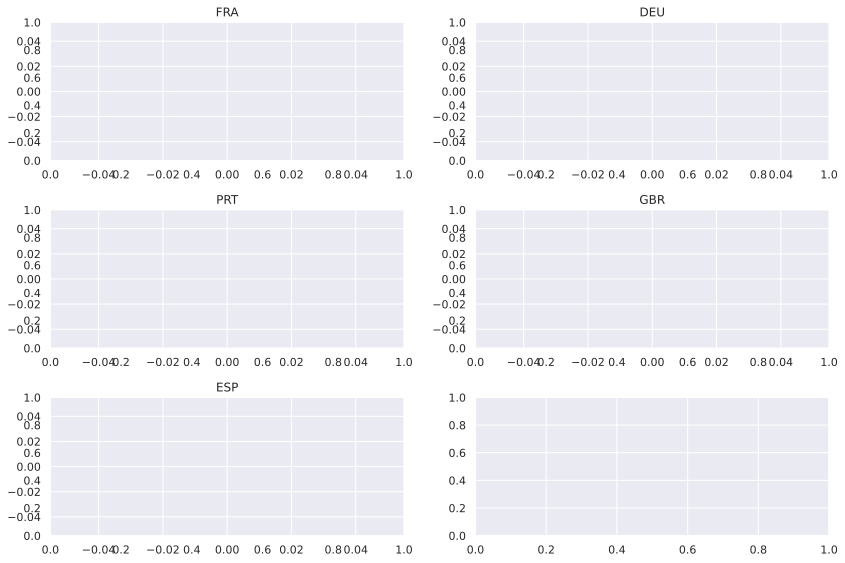

In [13]:
fig , ax = plt.subplots(figsize = (12,8) , ncols=2 , nrows=3 , constrained_layout = True)
ncols , nrows = (2,3)
for i in range(1 , len(index_countries) + 1):
  ax = fig.add_subplot(nrows , ncols , i)
  ax.plot()
  ax.set_title(f"{index_countries[i-1]}")


plt.tight_layout()
plt.show()

/tmp/ipython-input-1644897232.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


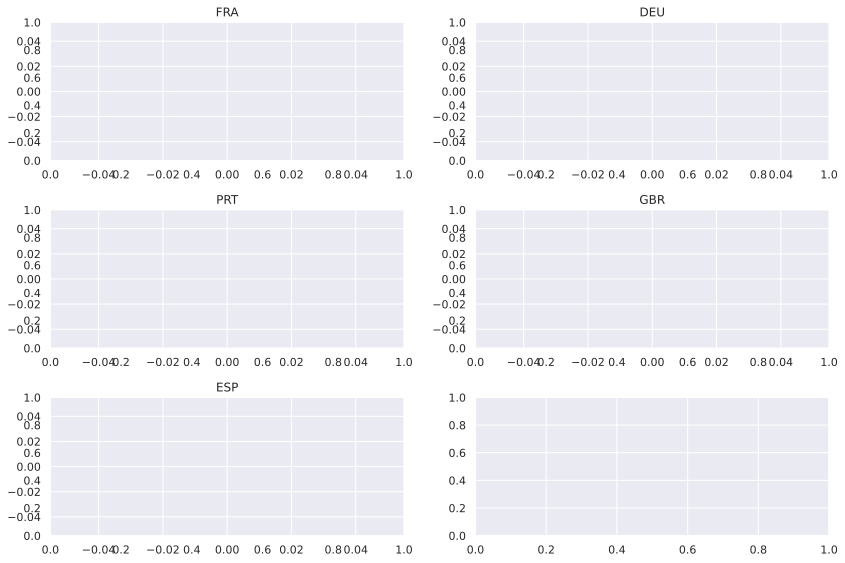

In [14]:
fig , ax = plt.subplots(figsize = (12,8) , ncols=2 , nrows=3 , constrained_layout = True)
ncols , nrows = (2,3)

ax_list = []

for i in range(1 , len(index_countries) + 1):
  ax = fig.add_subplot(nrows , ncols , i)
  ax.plot()
  ax.set_title(f"{index_countries[i-1]}")
  ax_list.append(ax)

plt.tight_layout()
plt.show()

In [15]:
ax_list

[<Axes: title={'center': 'FRA'}>,
 <Axes: title={'center': 'DEU'}>,
 <Axes: title={'center': 'PRT'}>,
 <Axes: title={'center': 'GBR'}>,
 <Axes: title={'center': 'ESP'}>]

In [16]:
ax_list[0]

<Axes: title={'center': 'FRA'}>

/tmp/ipython-input-3897814340.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


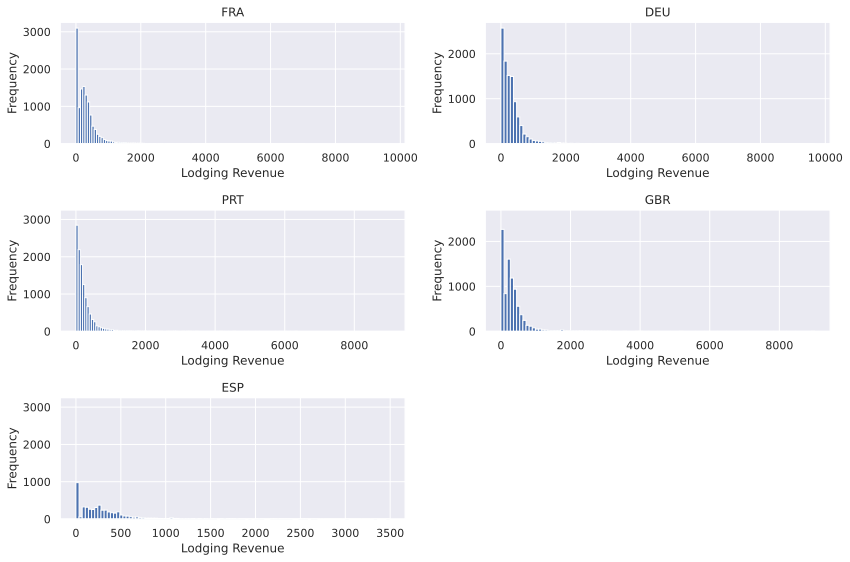

In [17]:
fig , ax_arr = plt.subplots(figsize = (12,8) , ncols=2 , nrows=3 , constrained_layout = True, sharex="row", sharey="col")

# Flatten the array of axes for easier iteration
ax_flat = ax_arr.flatten()

# Populate the subplots with histograms for each country
for i , country in enumerate(index_countries):
    current_ax = ax_flat[i] # Get the i-th axis from the flattened array
    # Plot histogram, filtering data for the current country and RoomNights < 15
    current_ax.hist(hotels.loc[(hotels.Nationality == country) & RoomNights_Mask, "LodgingRevenue"] , bins = 100)
    current_ax.set_title(f"{country}")
    current_ax.set_xlabel("Lodging Revenue") # Add x-axis title
    current_ax.set_ylabel("Frequency") # Add y-axis title

# Turn off any unused subplots (if number of countries is less than total grid slots)
# For 5 countries in a 2x3 grid (6 slots), the last subplot is unused.
for i in range(len(index_countries), len(ax_flat)):
    ax_flat[i].set_axis_off()

plt.tight_layout()
plt.show()

In [18]:
ax_flat

array([<Axes: title={'center': 'FRA'}, xlabel='Lodging Revenue', ylabel='Frequency'>,
       <Axes: title={'center': 'DEU'}, xlabel='Lodging Revenue', ylabel='Frequency'>,
       <Axes: title={'center': 'PRT'}, xlabel='Lodging Revenue', ylabel='Frequency'>,
       <Axes: title={'center': 'GBR'}, xlabel='Lodging Revenue', ylabel='Frequency'>,
       <Axes: title={'center': 'ESP'}, xlabel='Lodging Revenue', ylabel='Frequency'>,
       <Axes: >], dtype=object)

In [19]:
ax_flat[0]

<Axes: title={'center': 'FRA'}, xlabel='Lodging Revenue', ylabel='Frequency'>

# Assignment 2: GridSpec

* Build a Gridspec layout with a line chart plotting Lodging Revenue Vs. Hotel Revenue for all countries at the top of your report.

* Build a bar chart of total revenue (Lodging + Other Revenue) by country for our top 5 countries

* Build a Donut Chart Specifying 67% of the way to our Goal of French Revenue for the year

In [20]:
hotels["DaysSinceCreation"]

,DaysSinceCreation
0,150
1,1095
2,1095
3,1095
4,1095
...,...
83585,0
83586,0
83587,0
83588,0


In [21]:
pd.to_timedelta(hotels["DaysSinceCreation"] , unit = "D")

,DaysSinceCreation
0,150 days
1,1095 days
2,1095 days
3,1095 days
4,1095 days
...,...
83585,0 days
83586,0 days
83587,0 days
83588,0 days


In [22]:
hotels = hotels.assign(
    date = pd.to_datetime("2018-12-31") - pd.to_timedelta(hotels["DaysSinceCreation"], unit="D"),
    total_revenue = hotels["LodgingRevenue"] + hotels["OtherRevenue"]
)

# Prep Data For Line Chart

In [23]:
hotels[["date" , "total_revenue"]].head(5)

,date,total_revenue
0,2018-08-03,476.3
1,2016-01-01,333.0
2,2016-01-01,0.0
3,2016-01-01,300.0
4,2016-01-01,0.0


In [24]:
pd.concat([hotels.groupby(["Nationality"]).agg({"LodgingRevenue":"sum"}).nlargest(5,"LodgingRevenue") ,
           hotels.groupby(["Nationality"]).agg({"OtherRevenue":"sum"}).nlargest(5,"OtherRevenue") ,
           hotels.groupby(["Nationality"]).agg({"total_revenue":"sum"}).nlargest(5,"total_revenue")] ,
          axis = 1)

,LodgingRevenue,OtherRevenue,total_revenue
Nationality,,,
FRA,3809315.59,1033166.30,4842481.89
DEU,3113382.55,725541.53,3838924.08
PRT,2715008.72,665634.58,3380643.30
GBR,2693123.61,591212.77,3284336.38
ESP,1475909.33,319840.82,1795750.15


In [ ]:
# Prep Data For Bar Chart

In [25]:
hotels.groupby(["Nationality"]).agg({"total_revenue":"max"})

,total_revenue
Nationality,
ABW,899.5
AGO,7414.0
AIA,1099.5
ALB,667.1
AND,2411.0
...,...
WLF,137.2
WSM,342.0
YEM,0.0


In [26]:
top_5_countries_total_rev = hotels.groupby(["Nationality"]).agg({"total_revenue":"sum"}).nlargest(5 , "total_revenue")
top_5_countries_total_rev

,total_revenue
Nationality,
FRA,4842481.89
DEU,3838924.08
PRT,3380643.30
GBR,3284336.38
ESP,1795750.15


In [27]:
hotels.loc[(hotels.Nationality == "FRA") , ["LodgingRevenue" , "total_revenue"]]

,LodgingRevenue,total_revenue
3,240.0,300.0
4,0.0,0.0
7,535.0,629.0
8,0.0,0.0
11,292.0,373.0
...,...,...
83573,0.0,0.0
83574,358.0,466.0
83575,0.0,0.0
83576,0.0,0.0


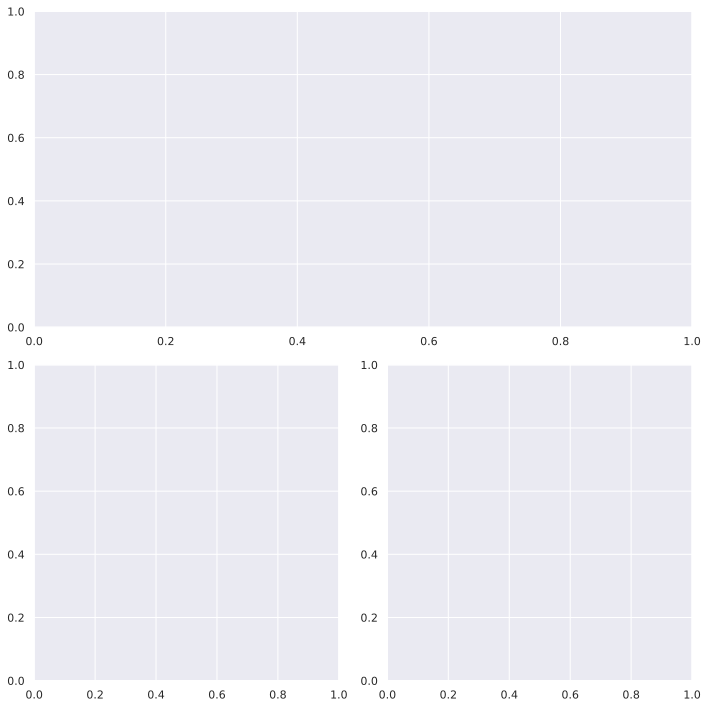

In [28]:
# Build GridSpec
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(10,10))
gs = gridspec.GridSpec(nrows=10 , ncols=10)

ax1 = fig.add_subplot(gs[0:5 , :])
ax2 = fig.add_subplot(gs[5: , 0:5])
ax3 = fig.add_subplot(gs[5:,5:])

plt.tight_layout()

In [29]:
monthly_revenue = (
    hotels.
    groupby("date").
    agg({"LodgingRevenue":"sum" , "OtherRevenue":"sum", "total_revenue":"sum"}).
    resample("ME").
    sum()
    )
monthly_revenue

,LodgingRevenue,OtherRevenue,total_revenue
date,,,
2016-01-31,124531.34,52190.50,176721.84
2016-02-29,131689.12,51203.13,182892.25
2016-03-31,443476.86,127336.11,570812.97
2016-04-30,500966.80,145228.87,646195.67
2016-05-31,634200.17,143359.35,777559.52
2016-06-30,588701.29,151214.74,739916.03
2016-07-31,749828.61,210745.90,960574.51
2016-08-31,842445.29,238536.04,1080981.33
2016-09-30,774270.05,181678.34,955948.39


In [30]:
(top_5_countries_total_rev / top_5_countries_total_rev.sum() * 100).round(2)

,total_revenue
Nationality,
FRA,28.25
DEU,22.39
PRT,19.72
GBR,19.16
ESP,10.48


In [31]:
top_5_countries_total_rev.iloc[0].div(top_5_countries_total_rev.sum())

,0
total_revenue,0.28249


In [32]:
top_5_countries_total_rev

,total_revenue
Nationality,
FRA,4842481.89
DEU,3838924.08
PRT,3380643.30
GBR,3284336.38
ESP,1795750.15


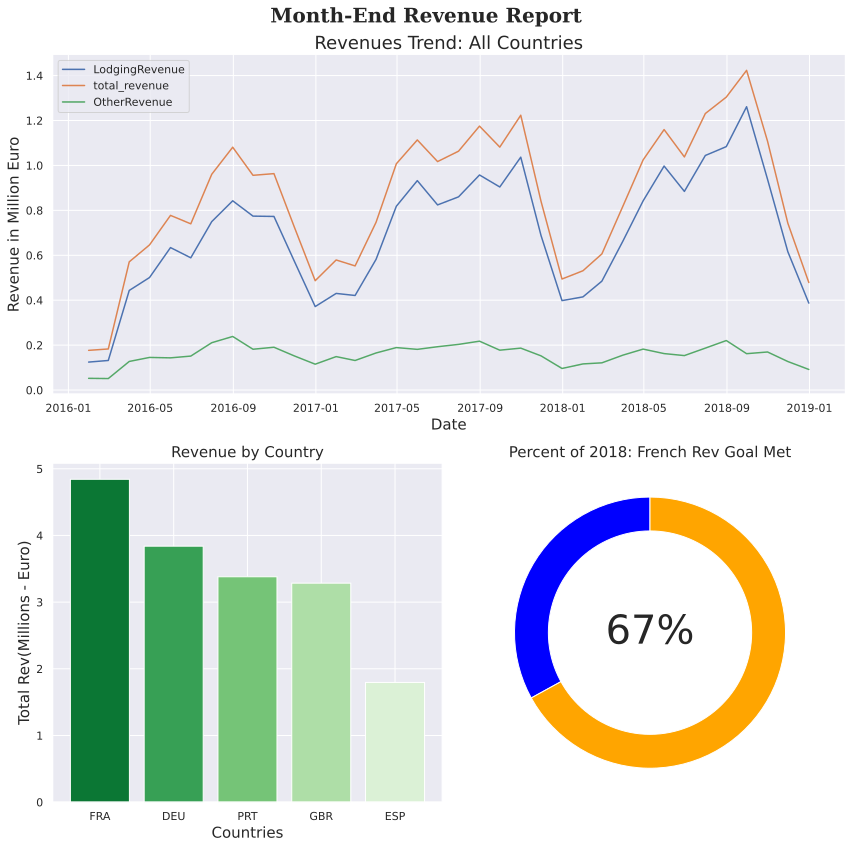

In [33]:
# Build GridSpec
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

fig = plt.figure(figsize=(12,12))
gs = gridspec.GridSpec(nrows=10 , ncols=10)

fig.suptitle("Month-End Revenue Report" , fontsize = 20 , fontweight = "bold" , fontfamily = "serif")


ax1 = fig.add_subplot(gs[0:5 , :])
ax1.set_title("Revenues Trend: All Countries" , fontsize = 18)

# Apply Set2 Colormap

ax1.plot(monthly_revenue.index , monthly_revenue.LodgingRevenue/(10**6))
ax1.plot(monthly_revenue.index , monthly_revenue.total_revenue/(10**6))
ax1.plot(monthly_revenue.index , monthly_revenue.OtherRevenue/(10**6))
ax1.legend(["LodgingRevenue" , "total_revenue", "OtherRevenue"])
ax1.set_ylabel("Revenue in Million Euro", fontsize = 15)
ax1.set_xlabel("Date", fontsize = 15)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)


# Bar Chart (ax2)
ax2 = fig.add_subplot(gs[5: , 0:5])
ax2.bar(top_5_countries_total_rev.index ,
        top_5_countries_total_rev.total_revenue/(10**6),
        color = sns.color_palette("Greens_r", n_colors=len(top_5_countries.index)))
ax2.set_title("Revenue by Country" , fontsize = 15 )
ax2.set_ylabel("Total Rev(Millions - Euro)", fontsize = 15)
ax2.set_xlabel("Countries" , fontsize = 15)


# Donut Chart (ax3)
ax3 = fig.add_subplot(gs[5:,5:])
# French Blue for first slice, white for secondary slice
ax3.pie([0.33 , 0.67], labels = ["" , ""] , colors = ["blue","orange"], startangle = 90)
ax3.set_title("Percent of 2018: French Rev Goal Met" , fontsize = 15 )
donut_hole = plt.Circle(xy = (0,0) , radius = 0.75 , fc = "white")
ax3.add_artist(donut_hole)
ax3.text(0,0,"67%", ha = "center", va = "center" , fontsize = 40)

plt.tight_layout()
plt.show()

# Assignment 3: Colors

* Apply the Set2 Colormap to the line chart.
* Look up the national colors of our top 5 countries and color each bar in the bar chart accordingly. The hex codes for colors can be looked up at https://flagcolor.com/.
* Finally, make the donut chart French Blue, and white out the secondary slice.

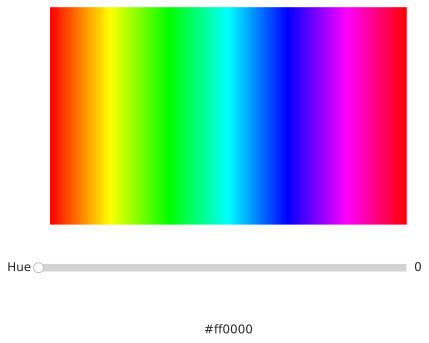

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.colors import hsv_to_rgb, to_hex

# Create hue spectrum
hues = np.linspace(0, 1, 256)
# Ensure input to hsv_to_rgb is a NumPy array with specified dtype to avoid ValueError with NumPy 2.0
gradient = hsv_to_rgb(np.vstack([hues, np.ones(256, dtype=np.float32), np.ones(256, dtype=np.float32)]).T.astype(np.float32))
gradient = gradient.reshape(1, 256, 3)

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

img = ax.imshow(gradient, aspect="auto")
ax.set_axis_off()

# Slider
ax_slider = plt.axes([0.1, 0.1, 0.8, 0.05])
slider = Slider(ax_slider, "Hue", 0, 1, valinit=0)

text = ax.text(0.5, -0.5, "", transform=ax.transAxes, ha="center")

def update(val):
    # Ensure input to hsv_to_rgb is a NumPy array with specified dtype to avoid ValueError with NumPy 2.0
    rgb = hsv_to_rgb(np.array([val, 1, 1], dtype=np.float32))
    hex_color = to_hex(rgb)
    text.set_text(hex_color)
    fig.canvas.draw_idle()

slider.on_changed(update)
update(0)

plt.show()

In [55]:
import matplotlib.colors as mcolors

colors = mcolors.get_named_colors_mapping()

# Example: print first 10
for name, hex_code in list(colors.items())[:10]:
    print(name, hex_code)


xkcd:cloudy blue #acc2d9
xkcd:dark pastel green #56ae57
xkcd:dust #b2996e
xkcd:electric lime #a8ff04
xkcd:fresh green #69d84f
xkcd:light eggplant #894585
xkcd:nasty green #70b23f
xkcd:really light blue #d4ffff
xkcd:tea #65ab7c
xkcd:warm purple #952e8f


In [56]:
for name, hex_code in list(colors.items()):
  if "red" in name:
    print(name ,hex_code)

xkcd:reddish grey #997570
xkcd:indian red #850e04
xkcd:neon red #ff073a
xkcd:red wine #8c0034
xkcd:orangered #fe420f
xkcd:pastel red #db5856
xkcd:darkish red #a90308
xkcd:reddy brown #6e1005
xkcd:rusty red #af2f0d
xkcd:lightish red #fe2f4a
xkcd:violet red #a50055
xkcd:dusty red #b9484e
xkcd:lipstick red #c0022f
xkcd:tomato red #ec2d01
xkcd:rose red #be013c
xkcd:purple red #990147
xkcd:orangish red #f43605
xkcd:brown red #922b05
xkcd:purplish red #b0054b
xkcd:rust red #aa2704
xkcd:orangey red #fa4224
xkcd:fire engine red #fe0002
xkcd:pink red #f5054f
xkcd:cherry red #f7022a
xkcd:faded red #d3494e
xkcd:red pink #fa2a55
xkcd:red purple #820747
xkcd:dull red #bb3f3f
xkcd:pinky red #fc2647
xkcd:red violet #9e0168
xkcd:burnt red #9f2305
xkcd:reddish #c44240
xkcd:wine red #7b0323
xkcd:reddish orange #f8481c
xkcd:brownish red #9e3623
xkcd:pale red #d9544d
xkcd:reddish purple #910951
xkcd:reddish pink #fe2c54
xkcd:orange red #fd411e
xkcd:deep red #9a0200
xkcd:red brown #8b2e16
xkcd:blood red #9

In [57]:
for name, hex_code in list(colors.items()):
  if "blue" in name:
    print(name ,hex_code)

xkcd:cloudy blue #acc2d9
xkcd:really light blue #d4ffff
xkcd:strong blue #0c06f7
xkcd:windows blue #3778bf
xkcd:blue blue #2242c7
xkcd:blue with a hint of purple #533cc6
xkcd:dark green blue #1f6357
xkcd:stormy blue #507b9c
xkcd:off blue #5684ae
xkcd:light royal blue #3a2efe
xkcd:dusk blue #26538d
xkcd:tiffany blue #7bf2da
xkcd:nice blue #107ab0
xkcd:ugly blue #31668a
xkcd:clear blue #247afd
xkcd:seafoam blue #78d1b6
xkcd:indigo blue #3a18b1
xkcd:green/blue #01c08d
xkcd:dark royal blue #02066f
xkcd:dark slate blue #214761
xkcd:flat blue #3c73a8
xkcd:rich blue #021bf9
xkcd:greenblue #23c48b
xkcd:warm blue #4b57db
xkcd:deep sea blue #015482
xkcd:very pale blue #d6fffe
xkcd:dark blue grey #1f3b4d
xkcd:light green blue #56fca2
xkcd:dodger blue #3e82fc
xkcd:metallic blue #4f738e
xkcd:bluey grey #89a0b0
xkcd:light light blue #cafffb
xkcd:vivid blue #152eff
xkcd:light greenish blue #63f7b4
xkcd:darkblue #030764
xkcd:vibrant blue #0339f8
xkcd:purple/blue #5d21d0
xkcd:bluegrey #85a3b2
xkcd:duck

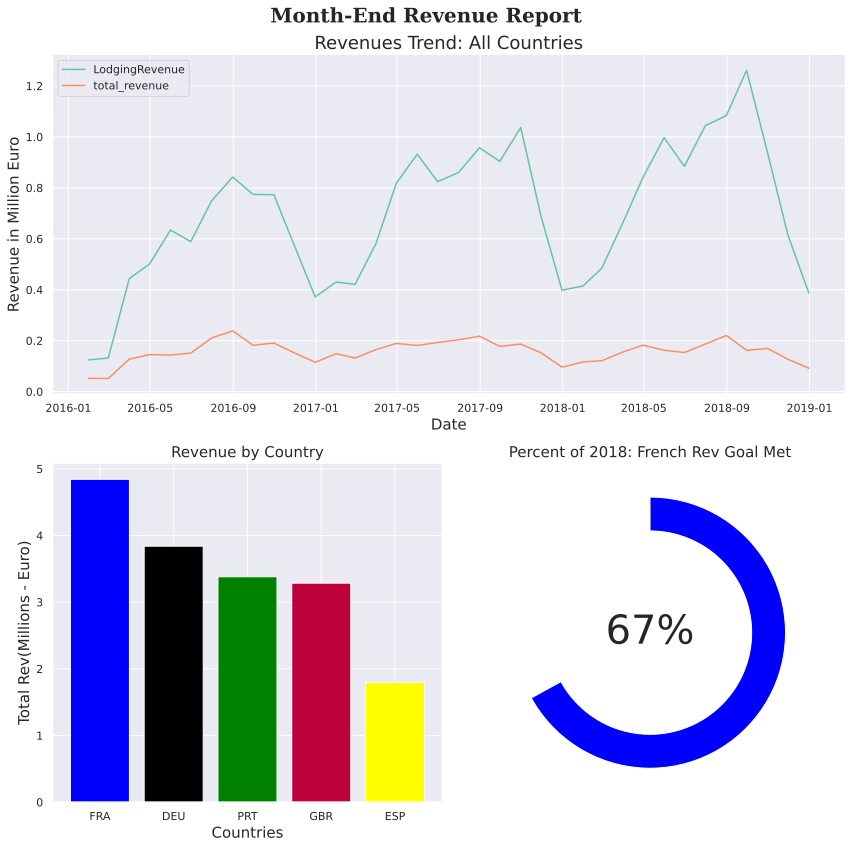

In [60]:
# Build GridSpec
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

fig = plt.figure(figsize=(12,12))
gs = gridspec.GridSpec(nrows=10 , ncols=10)

fig.suptitle("Month-End Revenue Report" , fontsize = 20 , fontweight = "bold" , fontfamily = "serif")

plt.rcParams["axes.prop_cycle"] = plt.cycler("color" , plt.cm.Set2.colors)
ax1 = fig.add_subplot(gs[0:5 , :])
ax1.set_title("Revenues Trend: All Countries" , fontsize = 18)

# Apply Set2 Colormap

ax1.plot(monthly_revenue.index , monthly_revenue.LodgingRevenue/(10**6))
#ax1.plot(monthly_revenue.index , monthly_revenue.total_revenue/(10**6))
ax1.plot(monthly_revenue.index , monthly_revenue.OtherRevenue/(10**6))
ax1.legend(["LodgingRevenue" , "total_revenue", "OtherRevenue"])
ax1.set_ylabel("Revenue in Million Euro", fontsize = 15)
ax1.set_xlabel("Date", fontsize = 15)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)


# Bar Chart (ax2)
colors = ["blue", "black", "green", "#be013c", "yellow"]
ax2 = fig.add_subplot(gs[5: , 0:5])
ax2.bar(top_5_countries_total_rev.index ,
        top_5_countries_total_rev.total_revenue/(10**6),
        color = colors)
ax2.set_title("Revenue by Country" , fontsize = 15 )
ax2.set_ylabel("Total Rev(Millions - Euro)", fontsize = 15)
ax2.set_xlabel("Countries" , fontsize = 15)


# Donut Chart (ax3)
ax3 = fig.add_subplot(gs[5:,5:])
# French Blue for first slice, white for secondary slice
ax3.pie([0.33 , 0.67], labels = ["" , ""] , colors = ["white","blue"], startangle = 90)
ax3.set_title("Percent of 2018: French Rev Goal Met" , fontsize = 15 )
donut_hole = plt.Circle(xy = (0,0) , radius = 0.75 , fc = "white")
ax3.add_artist(donut_hole)
ax3.text(0,0,"67%", ha = "center", va = "center" , fontsize = 40)

plt.tight_layout()
plt.show()

# Assignment 4: Stylesheets
* Apply a stylesheet to the above code

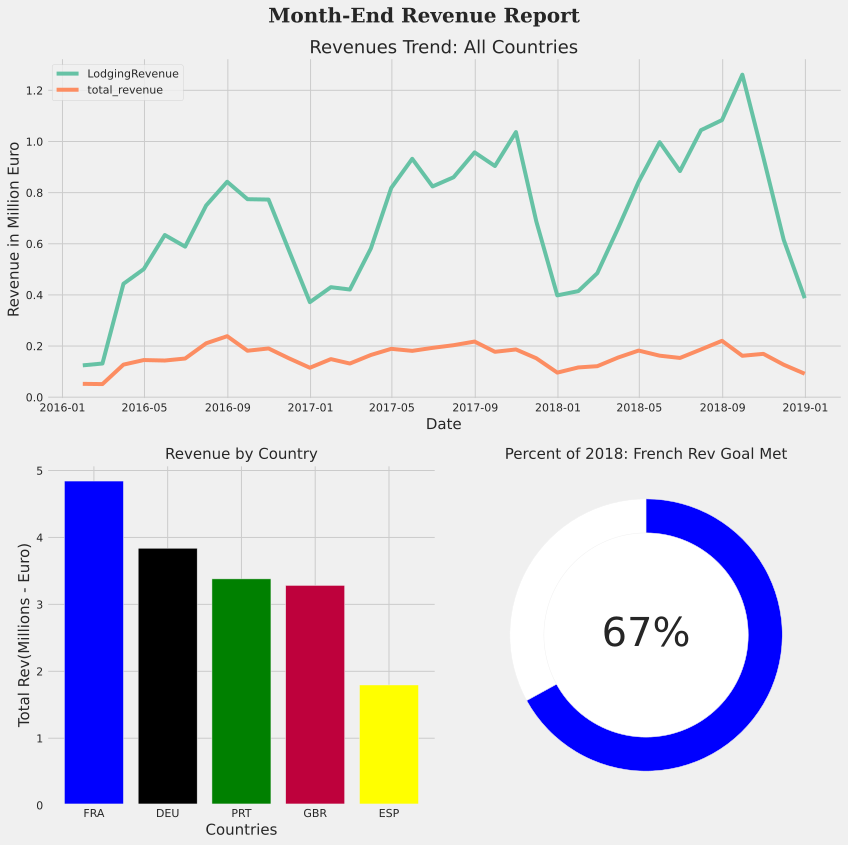

In [67]:
#sns.set_style("dark")
plt.style.use("fivethirtyeight")
# Build GridSpec
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

fig = plt.figure(figsize=(12,12))
gs = gridspec.GridSpec(nrows=10 , ncols=10)

fig.suptitle("Month-End Revenue Report" , fontsize = 20 , fontweight = "bold" , fontfamily = "serif")

plt.rcParams["axes.prop_cycle"] = plt.cycler("color" , plt.cm.Set2.colors)
ax1 = fig.add_subplot(gs[0:5 , :])
ax1.set_title("Revenues Trend: All Countries" , fontsize = 18)

# Apply Set2 Colormap

ax1.plot(monthly_revenue.index , monthly_revenue.LodgingRevenue/(10**6))
#ax1.plot(monthly_revenue.index , monthly_revenue.total_revenue/(10**6))
ax1.plot(monthly_revenue.index , monthly_revenue.OtherRevenue/(10**6))
ax1.legend(["LodgingRevenue" , "total_revenue", "OtherRevenue"])
ax1.set_ylabel("Revenue in Million Euro", fontsize = 15)
ax1.set_xlabel("Date", fontsize = 15)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)


# Bar Chart (ax2)
colors = ["blue", "black", "green", "#be013c", "yellow"]
ax2 = fig.add_subplot(gs[5: , 0:5])
ax2.bar(top_5_countries_total_rev.index ,
        top_5_countries_total_rev.total_revenue/(10**6),
        color = colors)
ax2.set_title("Revenue by Country" , fontsize = 15 )
ax2.set_ylabel("Total Rev(Millions - Euro)", fontsize = 15)
ax2.set_xlabel("Countries" , fontsize = 15)


# Donut Chart (ax3)
ax3 = fig.add_subplot(gs[5:,5:])
# French Blue for first slice, white for secondary slice
ax3.pie([0.33 , 0.67], labels = ["" , ""] , colors = ["white","blue"], startangle = 90)
ax3.set_title("Percent of 2018: French Rev Goal Met" , fontsize = 15 )
donut_hole = plt.Circle(xy = (0,0) , radius = 0.75 , fc = "white")
ax3.add_artist(donut_hole)
ax3.text(0,0,"67%", ha = "center", va = "center" , fontsize = 40)

plt.tight_layout()
plt.show()